# WWE Fan Engagement by Event Type
- Event Type: Televised, PPV/PEL, or Non-Televised

In [1]:
# Libraries 

import matplotlib.pyplot as plt
from matplotlib.image import imread
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import duckdb
import pandas as pd

# Establish Connection to Cyberduck

In [2]:
conn = duckdb.connect("/Users/marietolteca/Documents/MEDS/WWE-database/wwe_database.db")
cur = conn.cursor()

### Use Query to grab some data using database from Cyberduck

In [3]:
cur.execute("""
SELECT 
    YEAR(m.Date) AS Year,
    e.EventType,
    SUM(m.CageMatchRatingVotes) AS TotalVotes
FROM match_rating m
JOIN events e ON e.Date = m.Date AND e.Promotion = m.Promotion
GROUP BY Year, e.EventType
ORDER BY Year ASC, TotalVotes DESC;
""")

### Save cursor execution into a dataframe

In [4]:
# Save query from all superstars in Wrestlemania with most viewed total votes
df = cur.df()

### View First 10 Rows

In [5]:
print(df.head(10))

   Year      EventType  TotalVotes
0  2015        PLE/PPV     19092.0
1  2015      Televised     18994.0
2  2015  Non-Televised      5559.0
3  2016      Televised     35384.0
4  2016        PLE/PPV     22386.0
5  2016  Non-Televised     11158.0
6  2017        PLE/PPV     38968.0
7  2017  Non-Televised     18900.0
8  2017      Televised     18233.0
9  2018        PLE/PPV     41284.0


# Start Plot

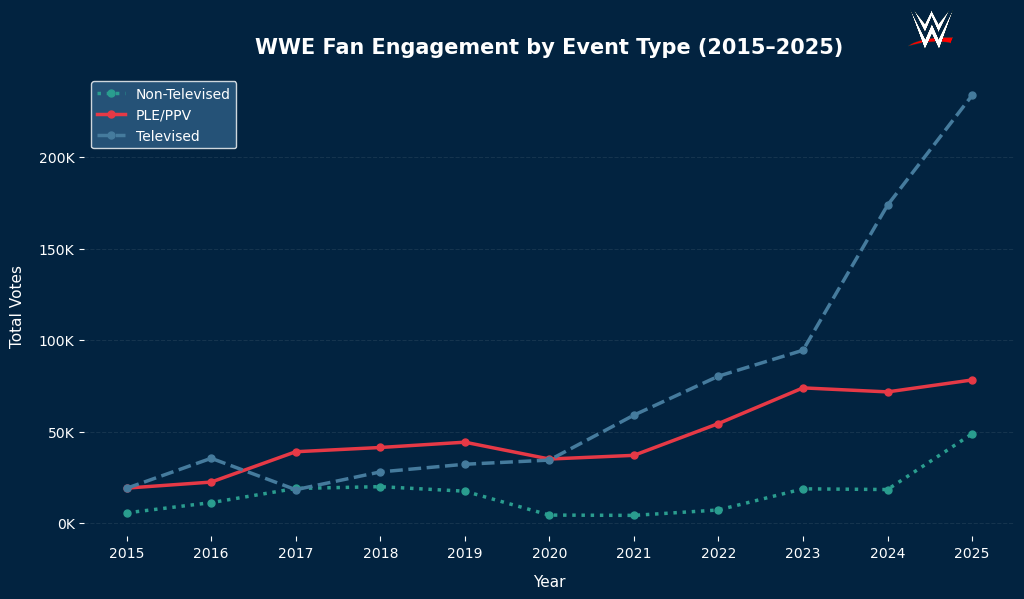

In [6]:

colors = {"PLE/PPV": "#e63946", "Televised": "#457b9d", "Non-Televised": "#2a9d8f"}
linestyles = {"PLE/PPV": "-", "Televised": "--", "Non-Televised": ":"}
bg_color = "#022340"

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

for etype, group in df.groupby("EventType"):
    group = group.sort_values("Year")
    ax.plot(group["Year"], group["TotalVotes"],
            label=etype,
            color=colors[etype],
            linestyle=linestyles[etype],
            linewidth=2.5,
            marker="o",
            markersize=5)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.set_xlabel("Year", color="white", fontsize=11, labelpad=10)
ax.set_ylabel("Total Votes", color="white", fontsize=11, labelpad=10)
ax.set_title("WWE Fan Engagement by Event Type (2015–2025)",
             color="white", fontsize=15, fontweight="bold", pad=15)

ax.tick_params(colors="white")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.grid(axis="y", color="white", alpha=0.08, linestyle="--")
ax.set_xticks(df["Year"].unique())

ax.legend(facecolor="#2e5f85", labelcolor="white", edgecolor="white",
          fontsize=10, framealpha=0.8)

# Add LOGO
logo = imread('../images/WWE-logo.png')
logo_ax = fig.add_axes([0.80, 0.02, 0.06, 1.87])  # [left, bottom, width, height]
logo_ax.imshow(logo)
logo_ax.axis("off")

# Save Plot
plt.savefig('../images/WWE_fan_engagement.png', dpi=150)

plt.show()

# Close Connection

In [7]:
conn.close()